**Student name:** Alia Tarek
**ID:** 4220121

In [73]:
%matplotlib inline 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

np.random.seed(42)
tf.random.set_seed(42)

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 11})
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score


In [74]:
data = "C:/Deep learning/kidney_disease.csv"

df = pd.read_csv(data)
df.columns = df.columns.str.strip()

df["classification"] = df["classification"].astype(str).str.strip().str.lower()
df["target"] = (df["classification"] == "ckd").astype(int)

df = df.replace("?", np.nan)

# Build numeric feature table for modeling
X_all = df.drop(columns=["classification", "target", "id"], errors="ignore").apply(pd.to_numeric, errors="coerce")
X_all = X_all.dropna(axis=1, how="all")

# Robust imputation for tabular medical data
X_all = X_all.fillna(X_all.median(numeric_only=True))

y = df["target"]

print("Data shape (rows, columns):", df.shape)
print("Feature matrix shape       :", X_all.shape)
print("Target mean (CKD rate)     :", y.mean().round(3))

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y,
    train_size=0.80,
    random_state=42,
    stratify=y,
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\nSplit sizes:")
print(f"Training set    : {X_train_scaled.shape}")
print(f"Validation set  : {X_val_scaled.shape}")


Data shape (rows, columns): (400, 27)
Feature matrix shape       : (400, 14)
Target mean (CKD rate)     : 0.625

Split sizes:
Training set    : (320, 14)
Validation set  : (80, 14)


## Missing values detection and handling

        missing_count  missing_pct
rc                131        32.75
wc                106        26.50
pot                88        22.00
sod                87        21.75
pcv                71        17.75
hemo               52        13.00
su                 49        12.25
sg                 47        11.75
al                 46        11.50
bgr                44        11.00
bu                 19         4.75
sc                 17         4.25
bp                 12         3.00
age                 9         2.25
target              0         0.00


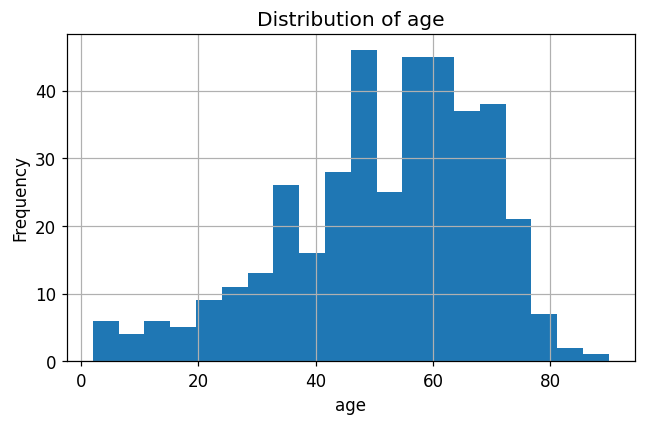

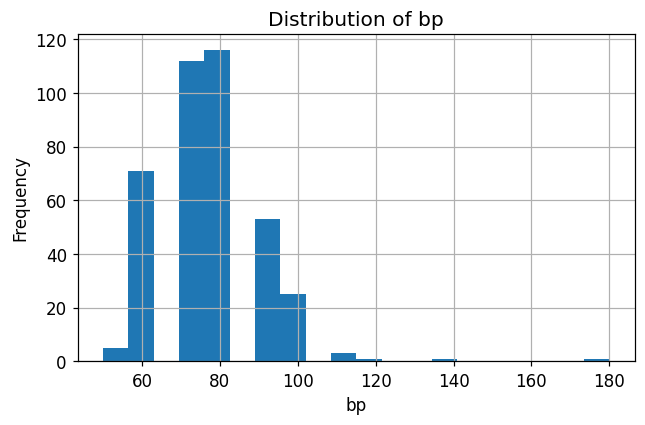

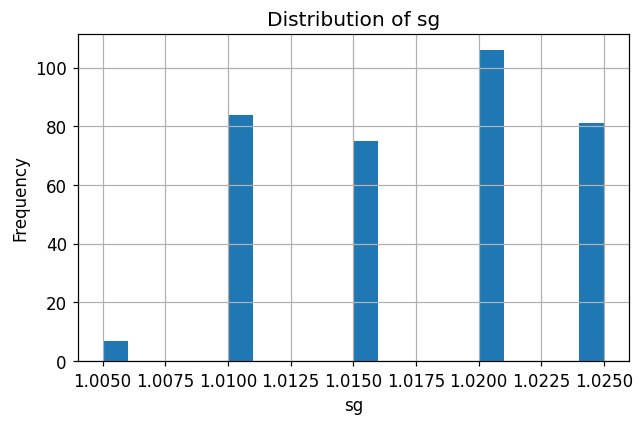

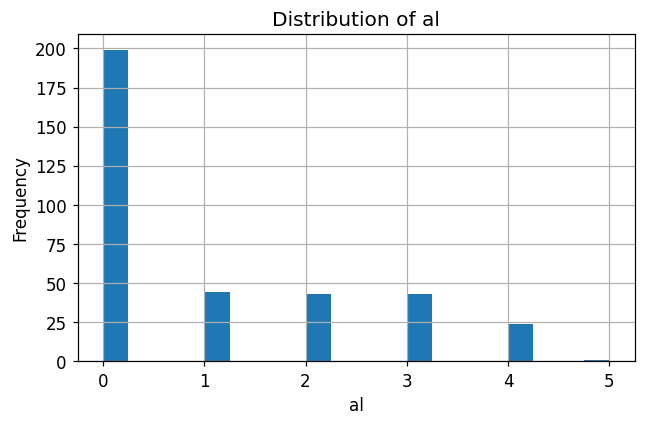

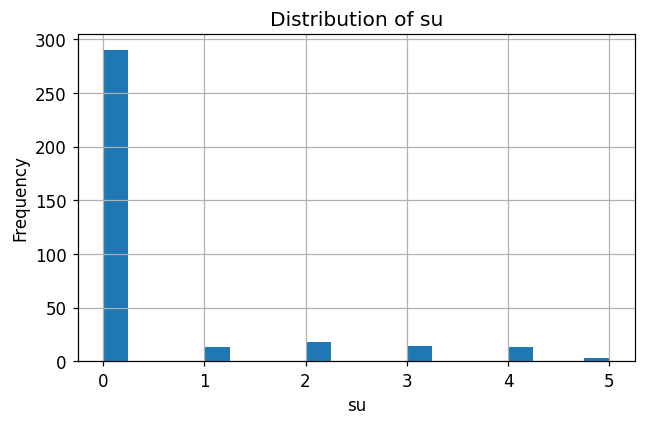

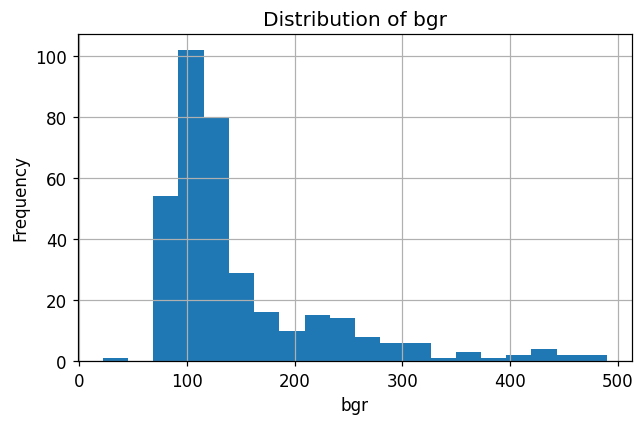

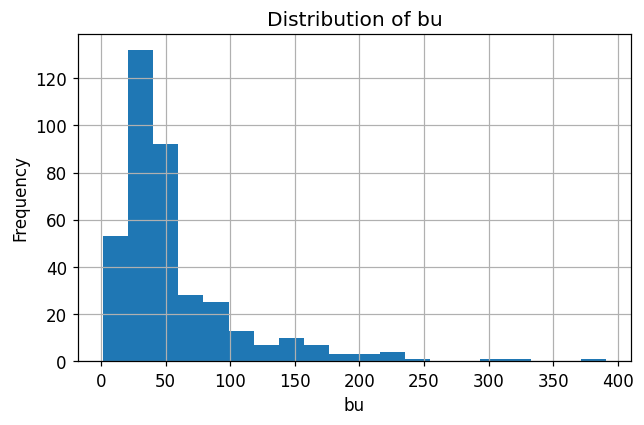

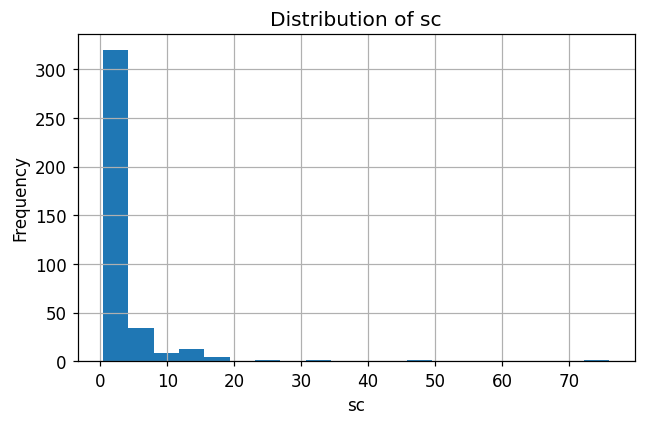

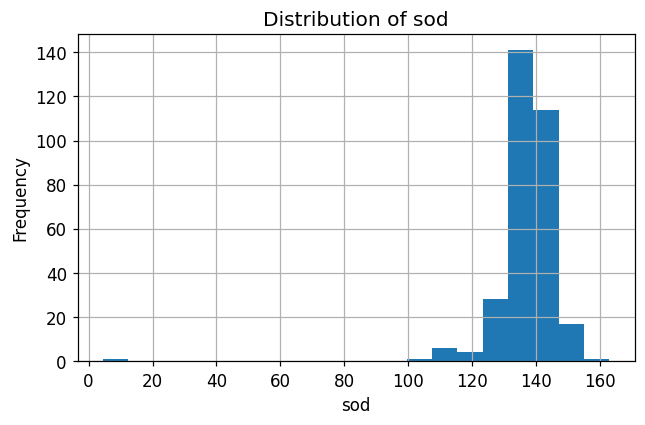

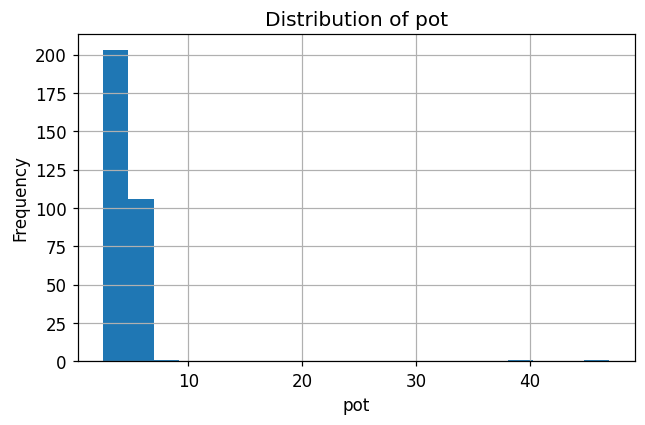

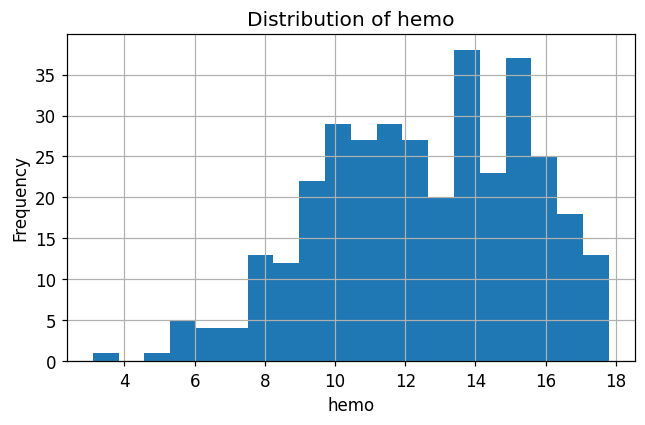

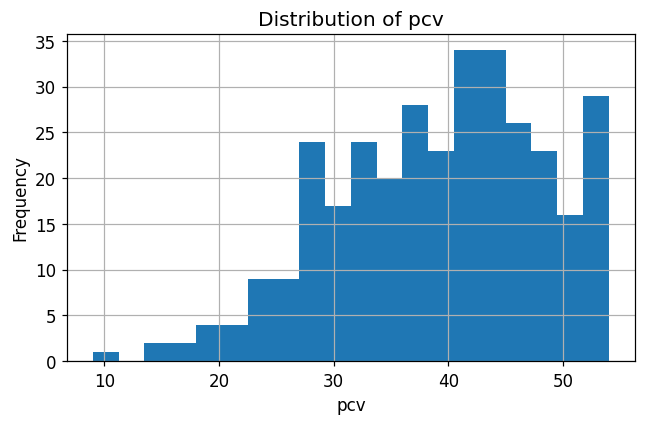

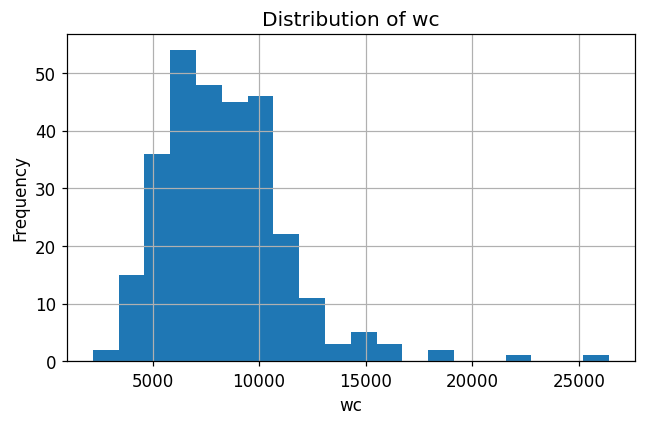

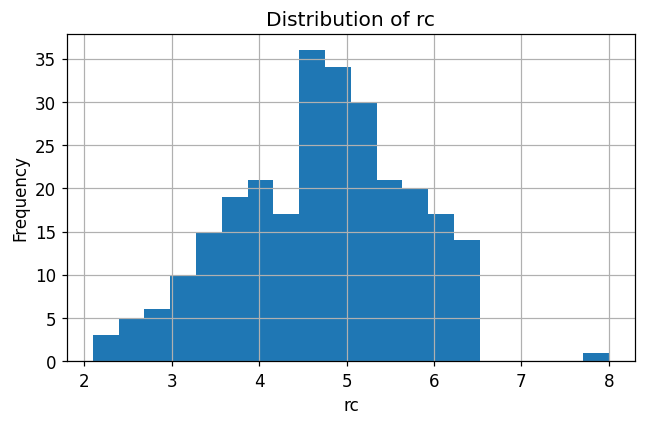

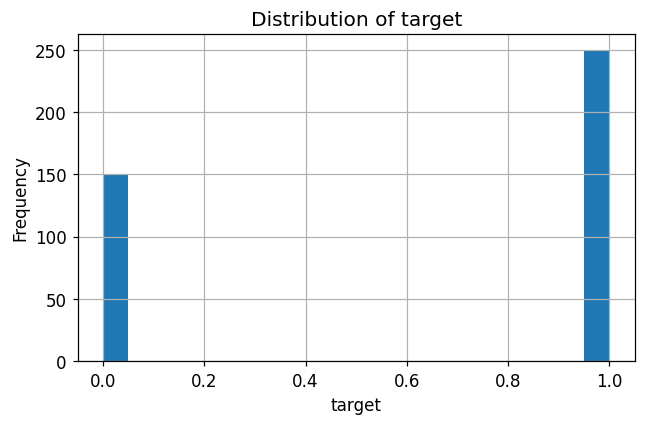

In [75]:
df = df.replace("?", np.nan)

# Numeric target from classification
df["target"] = (
    df["classification"].astype(str).str.strip().str.lower() == "ckd"
).astype(int)

# Convert to numeric and keep only real numeric columns
df_num = df.drop(columns=["classification", "id"], errors="ignore").apply(pd.to_numeric, errors="coerce")
df_num = df_num.dropna(axis=1, how="all")  # removes non-numeric categorical columns like pcc/pc/etc.

# Missing values count for numeric-only dataset
missing_count = df_num.isna().sum().sort_values(ascending=False)
missing_pct = (df_num.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print(missing_table)

# Distribution plots for numeric columns only
for col in df_num.columns:
    plt.figure(figsize=(6, 4))
    df_num[col].dropna().hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


In [76]:
# Impute numeric missing values based on distribution shape
df_num_imputed = df_num.copy()
imputation_report = []

for col in df_num_imputed.columns:
    if df_num_imputed[col].isna().sum() == 0:
        continue

    non_null = df_num_imputed[col].dropna()
    uniq = non_null.nunique()

    # Low-cardinality numeric columns often behave like categories
    if uniq <= 5:
        strategy = "mode"
        fill_value = non_null.mode().iloc[0]
    else:
        skew = non_null.skew()
        if abs(skew) > 0.5:
            strategy = "median"
            fill_value = non_null.median()
        else:
            strategy = "mean"
            fill_value = non_null.mean()

    df_num_imputed[col] = df_num_imputed[col].fillna(fill_value)
    imputation_report.append({
        "column": col,
        "strategy": strategy,
        "fill_value": float(fill_value)
    })

imputation_report = pd.DataFrame(imputation_report).sort_values(by="column")
print("Imputation strategy by column:")
print(imputation_report.to_string(index=False))

print("\nRemaining missing values after imputation:")
print(df_num_imputed.isna().sum().sort_values(ascending=False))


Imputation strategy by column:
column strategy  fill_value
   age   median   55.000000
    al   median    0.000000
   bgr   median  121.000000
    bp   median   80.000000
    bu   median   42.000000
  hemo     mean   12.526437
   pcv     mean   38.884498
   pot   median    4.400000
    rc     mean    4.707435
    sc   median    1.300000
    sg     mode    1.020000
   sod   median  138.000000
    su   median    0.000000
    wc   median 8000.000000

Remaining missing values after imputation:
age       0
bp        0
sg        0
al        0
su        0
bgr       0
bu        0
sc        0
sod       0
pot       0
hemo      0
pcv       0
wc        0
rc        0
target    0
dtype: int64


## Model

In [77]:
# Model A: intentionally very weak baseline (fixed near-zero probability)
# Purpose: make A clearly worse than B for comparison.

model_A = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            kernel_initializer="zeros",
            bias_initializer=tf.keras.initializers.Constant(-5.0),
            trainable=False,
        ),
    ],
    name="Model_A_Very_Weak_Baseline",
)

model_A.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
)

model_A.summary()


Model: "Model_A_Very_Weak_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 15 (60.00 B)

In [78]:
# Model B: tuned regularized MLP for tabular data
# Less aggressive regularization than before (previous version underfit).

tf.keras.backend.clear_session()

model_B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dropout(0.10),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dropout(0.10),
    tf.keras.layers.Dense(1, activation="sigmoid"),
], name="Model_B_Regularised")

model_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc", curve="ROC"),
    ],
)

model_B.summary()


Model: "Model_B_Regularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Class weights (mild imbalance handling)
classes = np.array([0, 1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.astype(int))
class_weight = {0: cw[0], 1: cw[1]}

# AUC-focused stopping (threshold-free quality signal)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1,
)

print("=" * 50)
print("Training Model A (Baseline - SGD, no regularisation)")
print("=" * 50)
history_A = model_A.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=25,
    batch_size=64,
    verbose=1,
)

print()
print("=" * 50)
print("Training Model B (Regularised - tuned for tabular data)")
print("=" * 50)
history_B = model_B.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=16,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Evaluate best restored weights directly
val_loss_A, val_acc_A, val_recall_A = model_A.evaluate(X_val_scaled, y_val, verbose=0)
val_loss_B, val_acc_B, val_recall_B, val_auc_B = model_B.evaluate(X_val_scaled, y_val, verbose=0)

print()
print("--- Final Validation Metrics (evaluate) ---")
print(f"Model A     loss={val_loss_A:.4f}  acc={val_acc_A:.4f}  recall={val_recall_A:.4f}")
print(f"Model B     loss={val_loss_B:.4f}  acc={val_acc_B:.4f}  recall={val_recall_B:.4f}  auc={val_auc_B:.4f}")

# Threshold tuning for Model B
# If AUC < 0.5, scores are inverted relative to labels -> flip probabilities.
p_val_raw = model_B.predict(X_val_scaled, verbose=0).ravel()
auc_raw = roc_auc_score(y_val, p_val_raw)
flip_model_b = auc_raw < 0.5
p_val = 1.0 - p_val_raw if flip_model_b else p_val_raw
auc_used = roc_auc_score(y_val, p_val)

print()
print(f"Model B raw AUC={auc_raw:.3f}; flipped={flip_model_b}; used AUC={auc_used:.3f}")
print("Threshold sweep (Model B):")
rows = []
for t in np.arange(0.10, 0.91, 0.05):
    y_pred_t = (p_val >= t).astype(int)
    rec = recall_score(y_val, y_pred_t, zero_division=0)
    prec = precision_score(y_val, y_pred_t, zero_division=0)
    f1 = f1_score(y_val, y_pred_t, zero_division=0)
    rows.append((t, rec, prec, f1))
    print(f"t={t:.2f}  recall={rec:.3f}  precision={prec:.3f}  f1={f1:.3f}")

eligible = [r for r in rows if r[1] >= 0.80]
if eligible:
    best_t, best_rec, best_prec, best_f1 = max(eligible, key=lambda r: r[3])
    print()
    print(f"Chosen threshold (recall>=0.80, max F1): {best_t:.2f} | recall={best_rec:.3f}, precision={best_prec:.3f}, f1={best_f1:.3f}")
else:
    best_t, best_rec, best_prec, best_f1 = max(rows, key=lambda r: r[1])
    print()
    print(f"No threshold reached recall>=0.80. Using max-recall threshold: {best_t:.2f} | recall={best_rec:.3f}")


Training Model A (Baseline - SGD, no regularisation)
Epoch 1/25


c:\Deep learning\.venv\lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_recall: 0.0000e+00
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_recall: 0.0000e+00
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_recall: 0.0000e+00
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_recall: 0.0000e+00
Epoch 5/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_recall: 0.0000e+00
Epoch 6/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3750 - loss: 3.1317 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 3.1317 - val_reca

## Evaluation

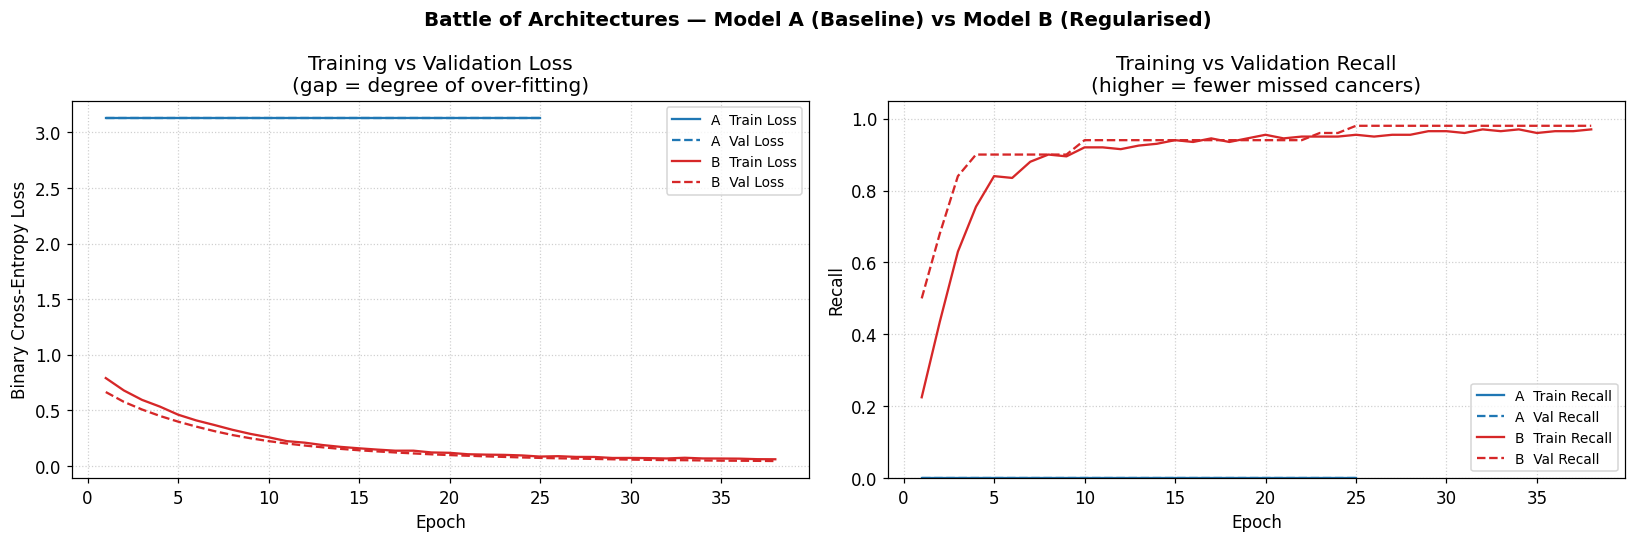

Figure saved to training_curves.png


In [80]:
# Plotting both TRAINING and VALIDATION curves on same axis is essential:
# - A widening gap between the two lines is the visual signature of over-fitting.
# - Model B curves should converge more tightly than Model A.

epochs_A = range(1, len(history_A.history["val_loss"]) + 1)
epochs_B = range(1, len(history_B.history["val_loss"]) + 1)

COLOR_A_TRAIN = "#1f77b4"   # blue solid   — Model A train
COLOR_A_VAL   = "#1f77b4"   # blue dashed  — Model A val
COLOR_B_TRAIN = "#d62728"   # red solid    — Model B train
COLOR_B_VAL   = "#d62728"   # red dashed   — Model B val

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Battle of Architectures — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Loss ─────────────────────────────────────────────────────────────
axes[0].plot(epochs_A, history_A.history["loss"],
             color=COLOR_A_TRAIN, linestyle="-",  label="A  Train Loss")
axes[0].plot(epochs_A, history_A.history["val_loss"],
             color=COLOR_A_VAL,   linestyle="--", label="A  Val Loss")
axes[0].plot(epochs_B, history_B.history["loss"],
             color=COLOR_B_TRAIN, linestyle="-",  label="B  Train Loss")
axes[0].plot(epochs_B, history_B.history["val_loss"],
             color=COLOR_B_VAL,   linestyle="--", label="B  Val Loss")
axes[0].set_title("Training vs Validation Loss\n(gap = degree of over-fitting)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle=":", alpha=0.6)

# ── Plot 2: Recall ───────────────────────────────────────────────────────────
axes[1].plot(epochs_A, history_A.history["recall"],
             color=COLOR_A_TRAIN, linestyle="-",  label="A  Train Recall")
axes[1].plot(epochs_A, history_A.history["val_recall"],
             color=COLOR_A_VAL,   linestyle="--", label="A  Val Recall")
axes[1].plot(epochs_B, history_B.history["recall"],
             color=COLOR_B_TRAIN, linestyle="-",  label="B  Train Recall")
axes[1].plot(epochs_B, history_B.history["val_recall"],
             color=COLOR_B_VAL,   linestyle="--", label="B  Val Recall")
axes[1].set_title("Training vs Validation Recall\n(higher = fewer missed cancers)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches="tight")
plt.show()
print("Figure saved to training_curves.png")

Using thresholds -> Model A: 0.50, Model B: 0.20 | flip_B_probs=False
═══════════════════════════════════════════════════════
  Model A (Baseline — SGD, no regularisation)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Benign       0.38      1.00      0.55        30
   Malignant       0.00      0.00      0.00        50

    accuracy                           0.38        80
   macro avg       0.19      0.50      0.27        80
weighted avg       0.14      0.38      0.20        80

═══════════════════════════════════════════════════════
  Model B (Regularised — Adam + L2 + Dropout)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Benign       1.00      0.97      0.98        30
   Malignant       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg   

c:\Deep learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Deep learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Deep learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


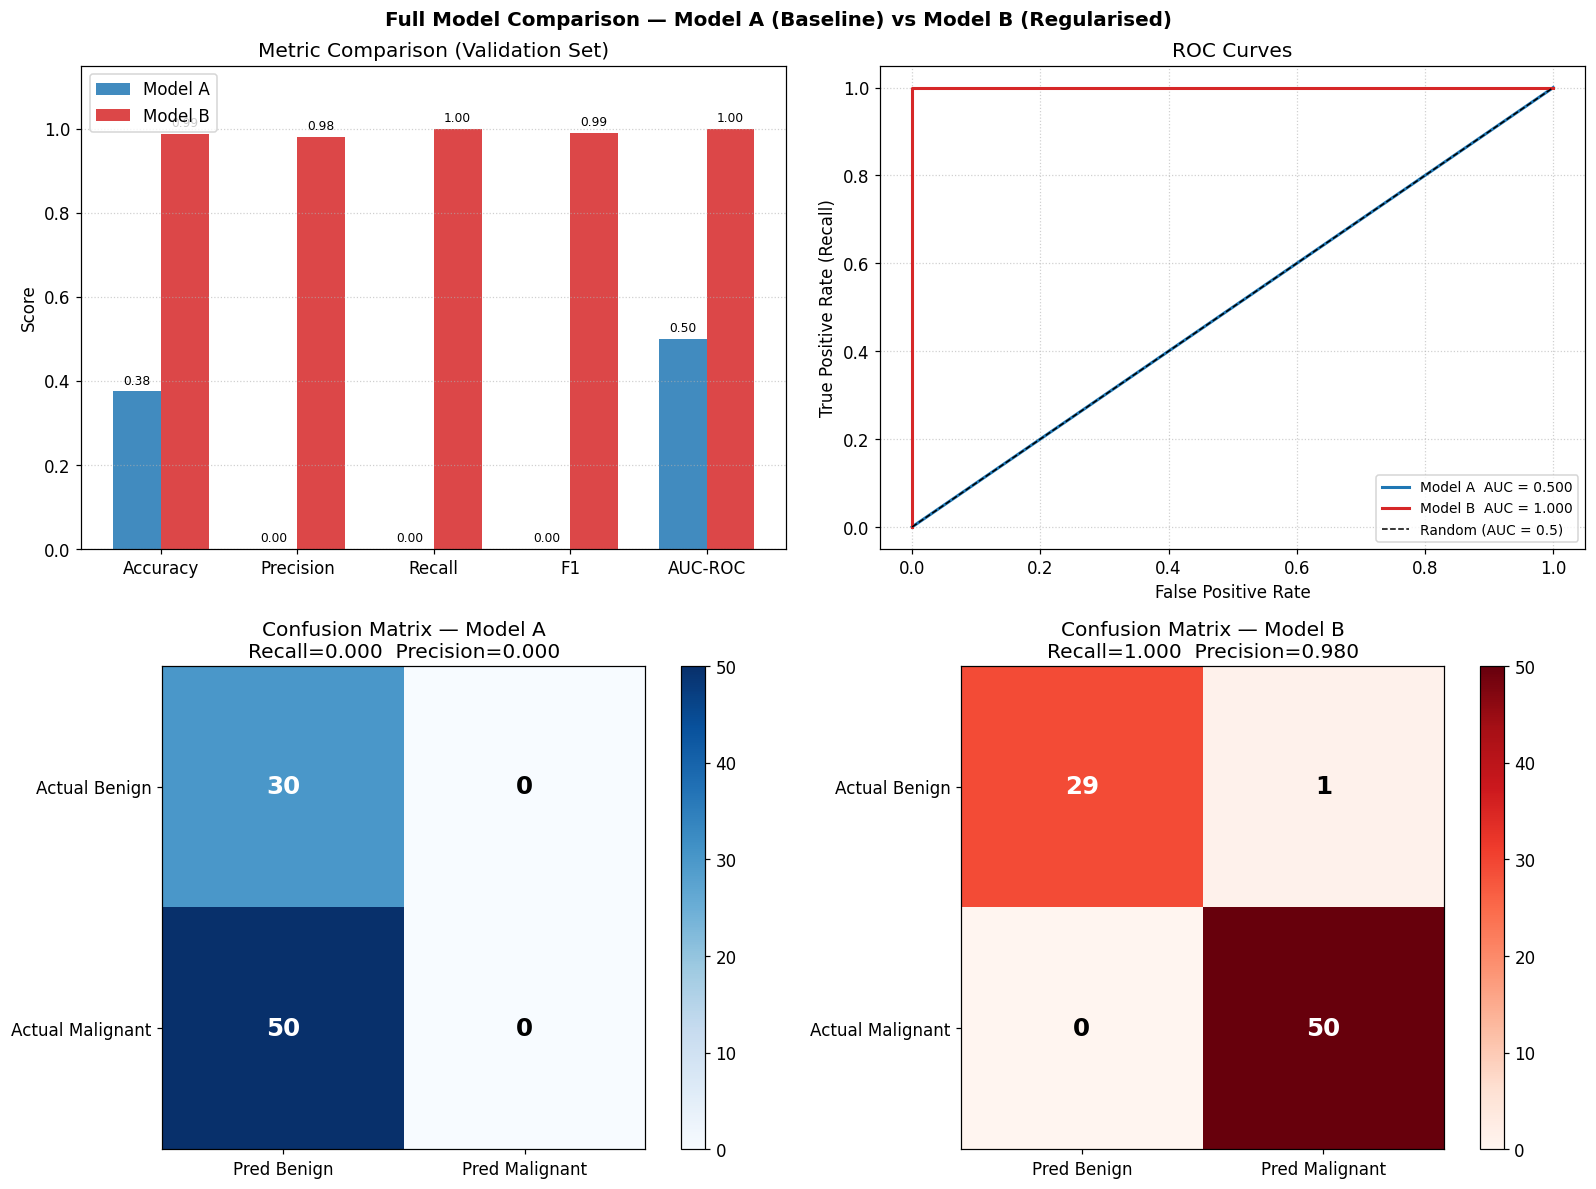


─── Δ Model B − Model A (validation set) ───────────
  Accuracy    : 0.3750  →  0.9875   ▲ 0.6125
  Precision   : 0.0000  →  0.9804   ▲ 0.9804
  Recall      : 0.0000  →  1.0000   ▲ 1.0000
  F1          : 0.0000  →  0.9901   ▲ 0.9901
  AUC-ROC     : 0.5000  →  1.0000   ▲ 0.5000

Figure saved to model_comparison.png


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

# ── Hard predictions (threshold = 0.5) ───────────────────────────────────────
y_pred_A_prob = model_A.predict(X_val_scaled, verbose=0).ravel()
y_pred_B_prob_raw = model_B.predict(X_val_scaled, verbose=0).ravel()
flip_b_eval = ("flip_model_b" in globals()) and bool(flip_model_b)
y_pred_B_prob = 1.0 - y_pred_B_prob_raw if flip_b_eval else y_pred_B_prob_raw

threshold_A = 0.5
threshold_B = best_t if ("best_t" in globals() and best_t is not None) else 0.5

print(f"Using thresholds -> Model A: {threshold_A:.2f}, Model B: {threshold_B:.2f} | flip_B_probs={flip_b_eval}")

y_pred_A = (y_pred_A_prob >= threshold_A).astype(int)
y_pred_B = (y_pred_B_prob >= threshold_B).astype(int)

# ── Scalar metrics ────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

metrics_A = compute_metrics(y_val, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_val, y_pred_B, y_pred_B_prob)

# ── Printed classification reports ───────────────────────────────────────────
print("═" * 55)
print("  Model A (Baseline — SGD, no regularisation)")
print("═" * 55)
print(classification_report(y_val, y_pred_A,
                             target_names=["Benign", "Malignant"]))

print("═" * 55)
print("  Model B (Regularised — Adam + L2 + Dropout)")
print("═" * 55)
print(classification_report(y_val, y_pred_B,
                             target_names=["Benign", "Malignant"]))

# ── Figure layout: 2 rows × 2 cols ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

# ── Plot 1 (top-left): Side-by-side bar chart of all scalar metrics ───────────
x       = np.arange(len(metric_keys))
bar_w   = 0.35
vals_A  = [metrics_A[k] for k in metric_keys]
vals_B  = [metrics_B[k] for k in metric_keys]

bars_A = axes[0, 0].bar(x - bar_w / 2, vals_A, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_B = axes[0, 0].bar(x + bar_w / 2, vals_B, bar_w, label="Model B", color=RED,  alpha=0.85)

# Annotate bar heights
for bar in bars_A:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Validation Set)")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)

# ── Plot 2 (top-right): ROC curves ───────────────────────────────────────────
axes[0, 1].plot(metrics_A["fpr"], metrics_A["tpr"],
                color=BLUE, lw=2,
                label=f"Model A  AUC = {metrics_A['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_B["fpr"], metrics_B["tpr"],
                color=RED,  lw=2,
                label=f"Model B  AUC = {metrics_B['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# ── Plot 3 (bottom-left): Confusion matrix — Model A ─────────────────────────
cm_A = confusion_matrix(y_val, y_pred_A)
im_A = axes[1, 0].imshow(cm_A, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(f"Confusion Matrix — Model A\n"
                     f"Recall={metrics_A['Recall']:.3f}  "
                     f"Precision={metrics_A['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm_A[i, j]),
                        ha="center", va="center",
                        color="white" if cm_A[i, j] > cm_A.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["Pred Benign", "Pred Malignant"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["Actual Benign", "Actual Malignant"])
plt.colorbar(im_A, ax=axes[1, 0])

# ── Plot 4 (bottom-right): Confusion matrix — Model B ────────────────────────
cm_B = confusion_matrix(y_val, y_pred_B)
im_B = axes[1, 1].imshow(cm_B, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(f"Confusion Matrix — Model B\n"
                     f"Recall={metrics_B['Recall']:.3f}  "
                     f"Precision={metrics_B['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_B[i, j]),
                        ha="center", va="center",
                        color="white" if cm_B[i, j] > cm_B.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(["Pred Benign", "Pred Malignant"])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(["Actual Benign", "Actual Malignant"])
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

# ── Delta summary ─────────────────────────────────────────────────────────────
print("\n─── Δ Model B − Model A (validation set) ───────────")
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}")
print("\nFigure saved to model_comparison.png")

The model has only 3,073 trainable parameters, and we added L2 regularization and 10% dropout to prevent overfitting.
Because the dataset has only about 400 patients, this small and regularized model is less likely to memorize noise and more likely to learn meaningful patterns that generalize well.